# Diabetes Dataset EDA

This notebook provides a detailed exploratory analysis of the diabetes dataset. It documents the dataset structure, cleaning steps, data quality checks, target distribution, and the main statistical patterns across features. A cleaned dataset is saved for downstream modeling.


## 0. Setup

Import libraries, configure display defaults, and define file paths along with the target column and candidate ID columns.


In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

RAW_PATH = Path("../data/raw/diabetes.csv")
PROCESSED_PATH = Path("../data/processed/diabetes_clean.csv")
TARGET_COL = "CLASS"
ID_COL_CANDIDATES = ["ID", "No_Pation"]

## 1. Load Data

Load the raw CSV into a working dataframe, report the dataset shape, and preview the first few rows to confirm column names and basic formatting.


In [16]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {RAW_PATH.resolve()}")

df_raw = pd.read_csv(RAW_PATH)
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
display(df.head())

Rows: 1,000 | Columns: 14


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


**Interpretation**

- The raw dataset contains **1,000 rows** and **14 columns**.
- Two ID-like fields (`ID`, `No_Pation`) are present in the raw file; these are identifiers rather than predictive features.
- The preview confirms the presence of clinical measurements (HbA1c, BMI, lipids, renal markers) and the target label (`CLASS`).


## 2. Schema and Data Types

`df.info()` summarizes the dataframe structure and data types for each column.


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(8), int64(4), str(2)
memory usage: 109.5 KB


**Interpretation**

- The dataset includes **4 integer**, **8 float**, and **2 object** columns.
- `Gender` and `CLASS` are categorical, while the remaining columns are numeric lab/clinical values.
- No missing values are reported in the schema view, which simplifies preprocessing.
- Memory usage is modest (**109.5 KB**), so the dataset is suitable for interactive analysis.


## 3. Descriptive Statistics (Numeric Columns)

`df.describe()` reports count, mean, standard deviation, and percentile summaries for numeric columns.


In [18]:
df.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


**Interpretation**

- **AGE**: median **55**, IQR **51-59**, range **20-79**.
- **HbA1c**: median **8.0**, range **0.9-16.0**, indicating wide glycemic variability.
- **BMI**: median **30.0**, range **19.0-47.75**, with moderate spread.
- **Urea** and **Cr** show large maxima (**38.9**, **800**), which signals heavy right tails.
- **VLDL** has a very high maximum (**35**), also indicating extreme values.
- ID-like columns (`ID`, `No_Pation`) appear in the raw file and are not modeled as features later.


## 4. Clean Column Text

Standardize column names and normalize categorical text fields (`CLASS`, `Gender`) to prevent duplicated categories caused by whitespace or case differences.


In [19]:
# Normalize column names
original_columns = df.columns.tolist()
df.columns = df.columns.str.strip()

# Clean common text fields if present
if TARGET_COL in df.columns:
    df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip()

if "Gender" in df.columns:
    df["Gender"] = df["Gender"].astype(str).str.strip().str.upper()

if original_columns != df.columns.tolist():
    print("Updated column names:")
    for before, after in zip(original_columns, df.columns.tolist()):
        if before != after:
            print(f"- '{before}' -> '{after}'")

**Interpretation**

- Column names are trimmed for consistency.
- `CLASS` values are normalized to remove stray whitespace.
- `Gender` values are converted to a consistent uppercase format (e.g., M/F).


## 6. Feature and Target Split

Remove identifier columns if present and separate the target (`CLASS`) from the feature set. This step also prints the resulting feature list.


In [21]:
id_cols = [c for c in ID_COL_CANDIDATES if c in df.columns]
feature_df = df.drop(columns=id_cols, errors="ignore")

feature_cols = [c for c in feature_df.columns if c != TARGET_COL]
X_df = feature_df[feature_cols]
y = feature_df[TARGET_COL] if TARGET_COL in feature_df.columns else None

print("Dropped ID columns:", id_cols)
print("Feature columns:", feature_cols)
if y is not None:
    print("Target column:", TARGET_COL)

Dropped ID columns: ['ID', 'No_Pation']
Feature columns: ['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
Target column: CLASS


**Interpretation**

- Dropped ID columns: ID, No_Pation.
- Feature set contains **11** columns: Gender, AGE, Urea, Cr, HbA1c, Chol, TG, HDL, LDL, VLDL, BMI.
- Target column (`CLASS`) is kept separately for analysis and modeling.


## 7. Save Cleaned Dataset

Persist a cleaned version of the dataset (with ID fields removed) to `data/processed/diabetes_clean.csv`.


In [22]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
clean_df = df.drop(columns=id_cols, errors="ignore")
clean_df.to_csv(PROCESSED_PATH, index=False)
print(f"Saved cleaned data (IDs removed) to: {PROCESSED_PATH.resolve()}")


Saved cleaned data (IDs removed) to: /Users/abhaydhakal/Documents/diabetes_prediction/data/processed/diabetes_clean.csv


**Interpretation**

- The cleaned dataset is now stored in the processed folder for consistent reuse in modeling notebooks.


## 8. Target Distribution

Visualize the class balance across the target labels.


,count
CLASS,
Y,844
N,103
P,53


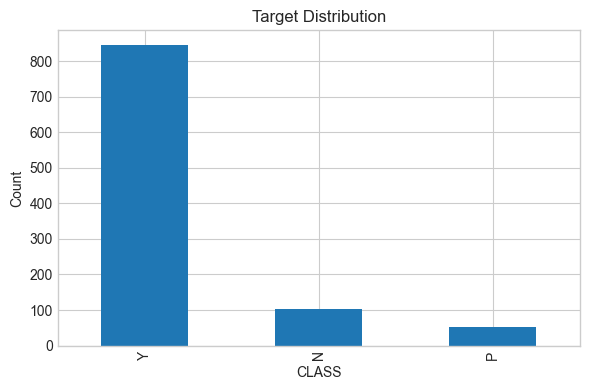

In [23]:
if y is None:
    print(f"Target column '{TARGET_COL}' not found.")
else:
    value_counts = y.value_counts(dropna=False)
    display(value_counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    value_counts.plot(kind="bar")
    plt.title("Target Distribution")
    plt.xlabel(TARGET_COL)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

**Interpretation**

- `Y`: 844 (84.4%)
- `N`: 103 (10.3%)
- `P`: 53 (5.3%)

`Y` dominates the dataset, while `N` and especially `P` are much smaller groups, indicating a strong class imbalance.


## 9. Numeric Feature Summary and Outliers

Summarize numeric features and compute IQR-based outlier counts. The IQR rule flags extreme values relative to the middle 50% of the data.


In [24]:
numeric_cols = X_df.select_dtypes(include="number").columns

if len(numeric_cols) == 0:
    print("No numeric columns detected.")
else:
    display(X_df[numeric_cols].describe().T)

    # Simple IQR-based outlier count
    def iqr_outlier_count(series: pd.Series) -> int:
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return int(((series < lower) | (series > upper)).sum())

    outlier_counts = {
        col: iqr_outlier_count(X_df[col].dropna())
        for col in numeric_cols
    }
    display(pd.Series(outlier_counts, name="iqr_outliers"))

    # Sanity checks for non-negative features
    non_negative_candidates = ["AGE", "BMI", "HbA1c", "Chol", "TG", "LDL", "HDL", "Cr", "Urea"]
    invalid = {
        col: int((X_df[col] < 0).sum())
        for col in non_negative_candidates
        if col in X_df.columns
    }
    if invalid:
        print("Negative value checks:")
        display(pd.Series(invalid, name="negative_count"))

,count,mean,std,min,25%,50%,75%,max
AGE,1000.0,53.528000,8.799241,20.0,51.0,55.0,59.0,79.00
Urea,1000.0,5.124743,2.935165,0.5,3.7,4.6,5.7,38.90
Cr,1000.0,68.943000,59.984747,6.0,48.0,60.0,73.0,800.00
HbA1c,1000.0,8.281160,2.534003,0.9,6.5,8.0,10.2,16.00
Chol,1000.0,4.862820,1.301738,0.0,4.0,4.8,5.6,10.30
TG,1000.0,2.349610,1.401176,0.3,1.5,2.0,2.9,13.80
HDL,1000.0,1.204750,0.660414,0.2,0.9,1.1,1.3,9.90
LDL,1000.0,2.609790,1.115102,0.3,1.8,2.5,3.3,9.90
VLDL,1000.0,1.854700,3.663599,0.1,0.7,0.9,1.5,35.00
BMI,1000.0,29.578020,4.962388,19.0,26.0,30.0,33.0,47.75


AGE      98
Urea     65
Cr       52
HbA1c     6
Chol     27
TG       55
HDL      50
LDL      11
VLDL     74
BMI       3
Name: iqr_outliers, dtype: int64

Negative value checks:


AGE      0
BMI      0
HbA1c    0
Chol     0
TG       0
LDL      0
HDL      0
Cr       0
Urea     0
Name: negative_count, dtype: int64

**Interpretation**

IQR-based outlier counts by feature:

- AGE: 98
- Urea: 65
- Cr: 52
- HbA1c: 6
- Chol: 27
- TG: 55
- HDL: 50
- LDL: 11
- VLDL: 74
- BMI: 3

The largest outlier counts occur in **VLDL, AGE, Urea, TG, and Cr**, reflecting heavy-tailed distributions in these variables. These values may be clinically valid extremes rather than data errors.


## 10. Univariate Distributions

Plot histograms for each numeric feature to examine distribution shape.


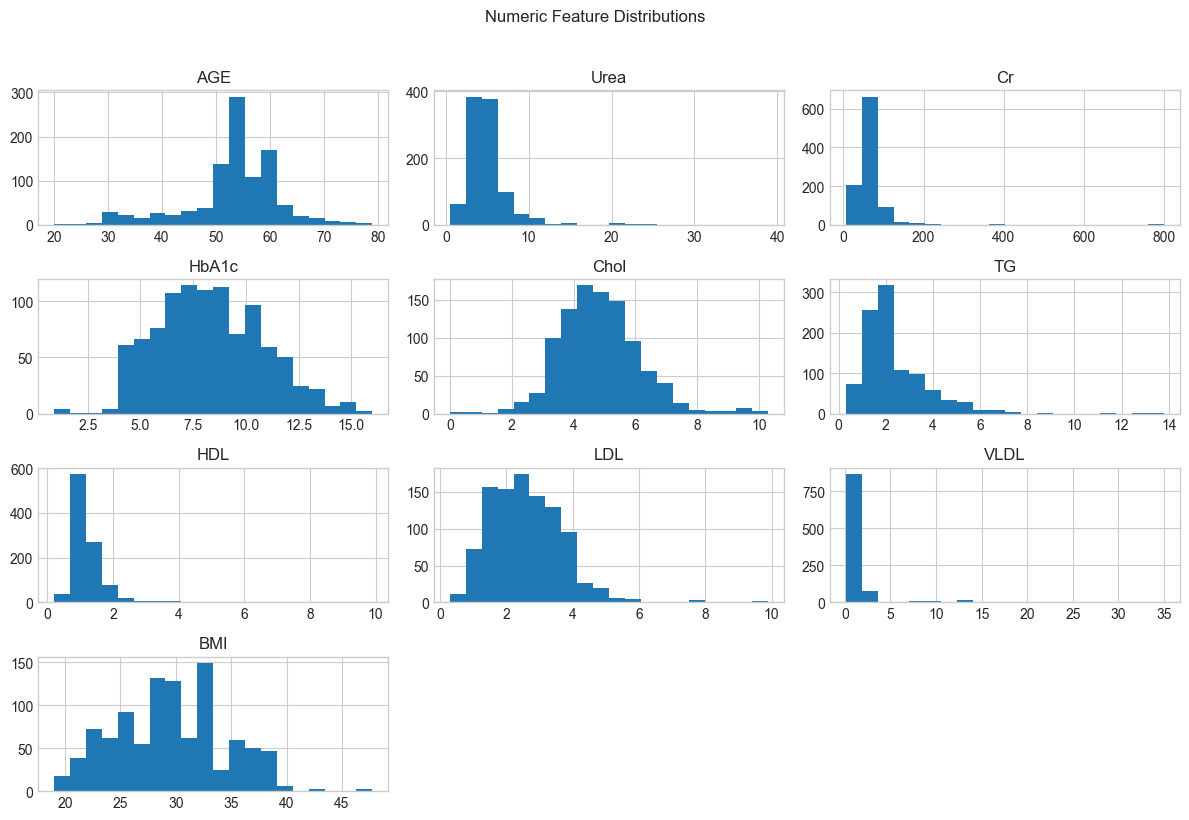

In [25]:
if len(numeric_cols) > 0:
    X_df[numeric_cols].hist(bins=20, figsize=(12, 8))
    plt.suptitle("Numeric Feature Distributions", y=1.02)
    plt.tight_layout()
    plt.show()

**Interpretation**

- **Right‑skewed features** (long high tails): Cr, HDL, VLDL, Urea, TG.
- **Moderate skew**: LDL and Chol.
- **Near‑symmetric**: HbA1c and BMI.
- **Left‑skewed**: AGE (skew ≈ -0.82), indicating more observations toward higher ages.

Skewness values (largest to smallest):
- Cr: 8.47, HDL: 6.28, VLDL: 5.35, Urea: 4.30, TG: 2.30
- LDL: 1.15, Chol: 0.62, HbA1c: 0.22, BMI: 0.13, AGE: -0.82


## 11. Target vs Feature (Boxplots)

Boxplots compare feature distributions across `CLASS` for selected numeric variables.


<Figure size 600x400 with 0 Axes>

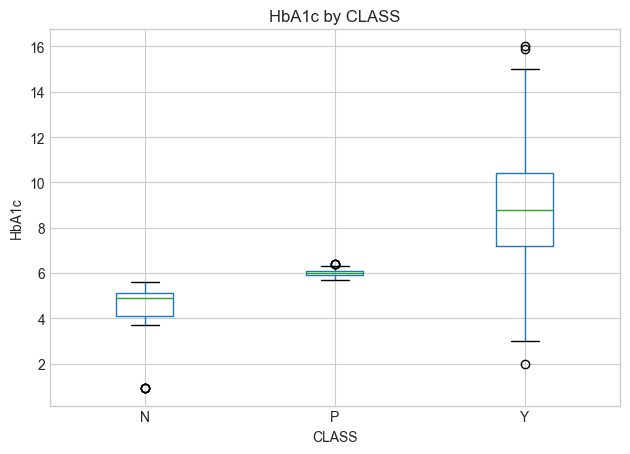

<Figure size 600x400 with 0 Axes>

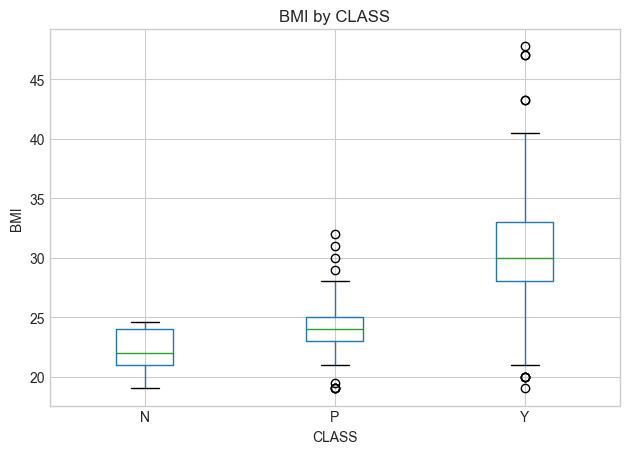

<Figure size 600x400 with 0 Axes>

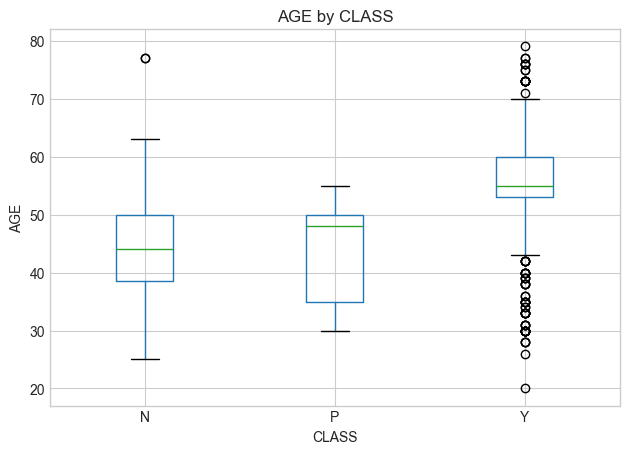

<Figure size 600x400 with 0 Axes>

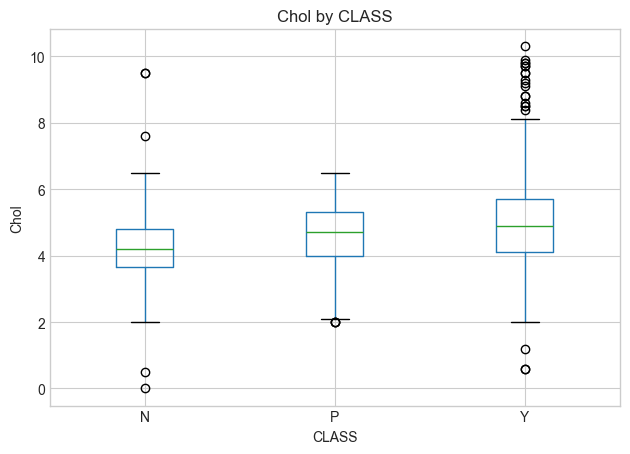

<Figure size 600x400 with 0 Axes>

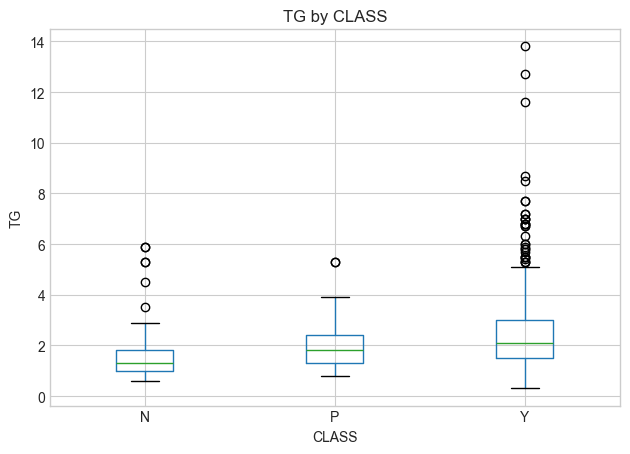

<Figure size 600x400 with 0 Axes>

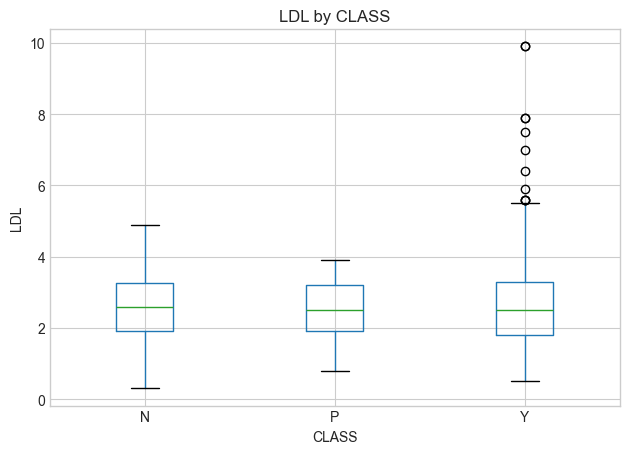

<Figure size 600x400 with 0 Axes>

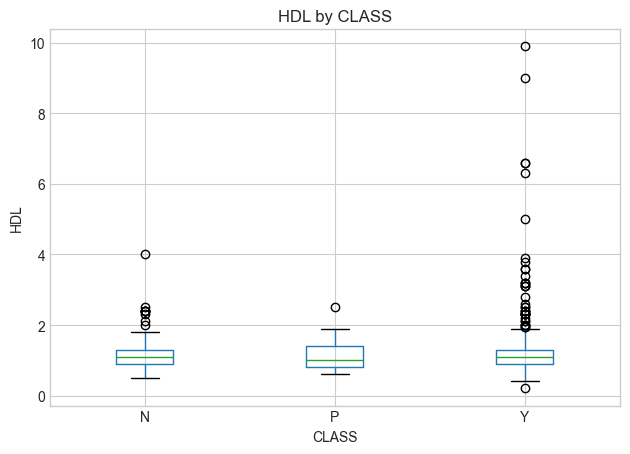

<Figure size 600x400 with 0 Axes>

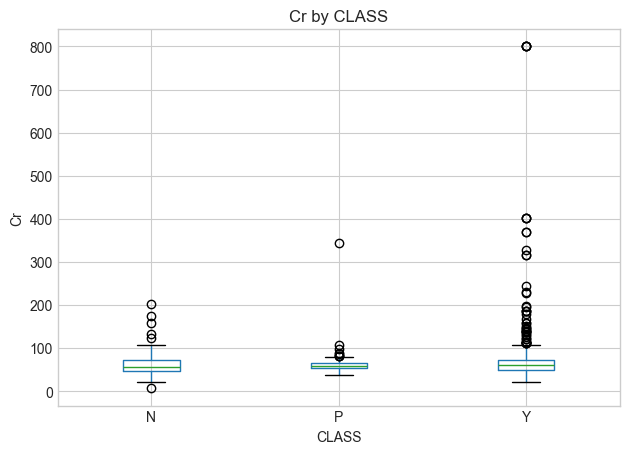

<Figure size 600x400 with 0 Axes>

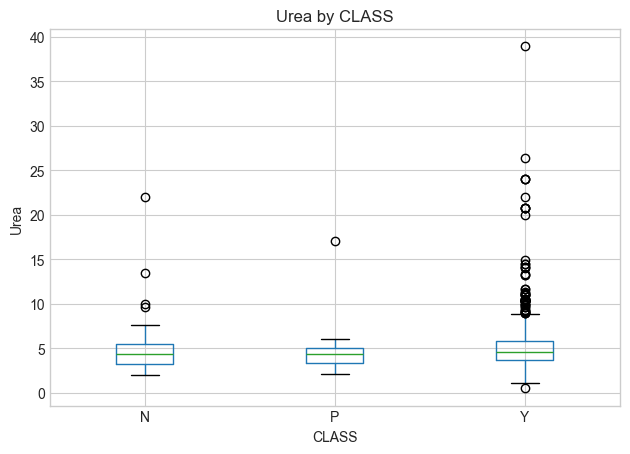

In [26]:
if y is None or len(numeric_cols) == 0:
    print("Skipping boxplots (missing target or numeric columns).")
else:
    cols = [c for c in ["HbA1c", "BMI", "AGE", "Chol", "TG", "LDL", "HDL", "Cr", "Urea"] if c in X_df.columns]
    for c in cols:
        plt.figure(figsize=(6, 4))
        df.boxplot(column=c, by=TARGET_COL)
        plt.title(f"{c} by {TARGET_COL}")
        plt.suptitle("")
        plt.xlabel(TARGET_COL)
        plt.ylabel(c)
        plt.tight_layout()
        plt.show()

**Interpretation**

Key median comparisons across classes:

- **HbA1c** increases from `N` (4.9) to `P` (6.0) to `Y` (8.8).
- **BMI** rises from 22.0 (N) to 24.0 (P) to 30.0 (Y).
- **AGE** increases across classes (medians 44, 48, 55).
- **TG** and **VLDL** are higher in `Y` (medians 2.1 and 1.0), while `N` is lowest.
- **Chol** shows a mild upward shift (medians 4.2 to 4.9).
- **LDL** and **HDL** largely overlap across classes, indicating weaker separation.
- **Cr** and **Urea** show small shifts with substantial overlap.

The `P` class has fewer observations, so its boxes appear narrower and more variable compared to `N` and `Y`.


## 12. Correlation Heatmap

The correlation matrix summarizes linear relationships between numeric features. Values range from -1 (strong negative) to +1 (strong positive).


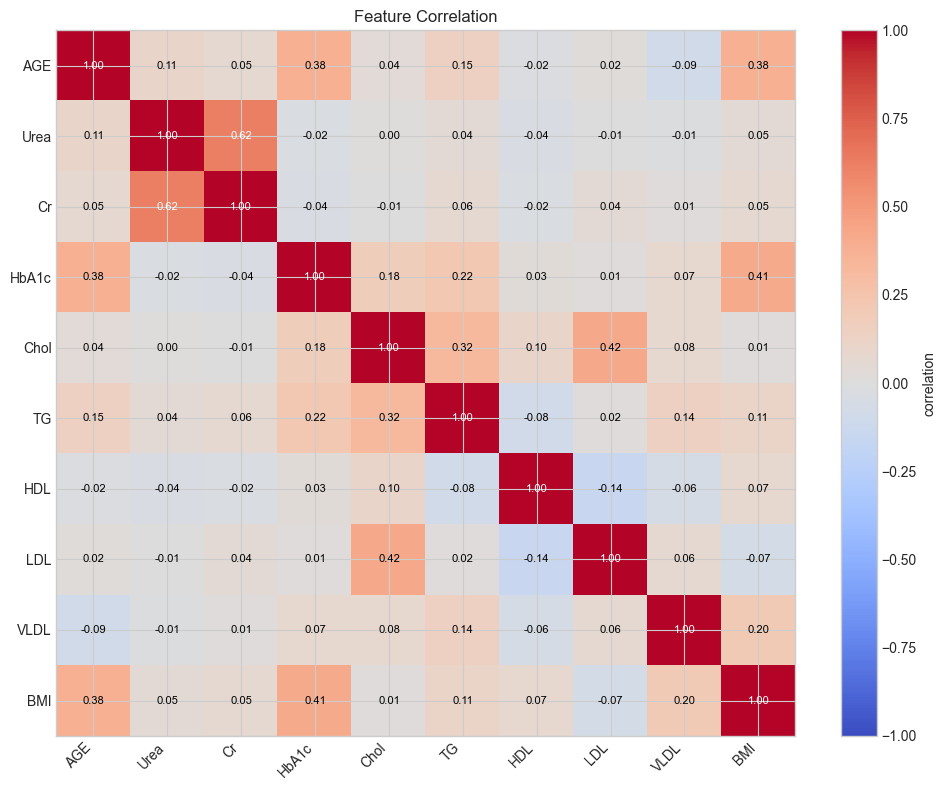

In [28]:
if len(numeric_cols) > 1:
    corr = X_df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, label="correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Feature Correlation")

    # annotate each cell with the correlation value
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            color = "white" if abs(val) > 0.5 else "black"
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation.")


**Interpretation**

Notable correlations in this dataset:

- Cr vs Urea: r = 0.62
- Chol vs LDL: r = 0.42
- HbA1c vs BMI: r = 0.41
- AGE vs HbA1c: r = 0.38
- AGE vs BMI: r = 0.38
- TG vs Chol: r = 0.32

No strong negative correlations are observed; most feature pairs are weakly related or nearly independent.

Overall, correlations are mostly weak to moderate, with the strongest relationships among clinically related measures (lipids and renal markers).
